# Preprocessing

The scripts here convert the raw records into timeseries used for the dataanalysis

Source records: https://zenodo.org/records/14199027

## Parameters

min_dt_sec: minimum timedifference between successive timesteps

max_dt_sec: maximum timedifference between successive timesteps

min_ts_duration_sec: minimum duration, minimum number of entries and maximum timedifference between successive timesteps

min_ts_nsamp: minimum number of entries

max_dpos_m: threshold for large displacements

stdev_position_meters: the standarddeviation of the 

(optional) grounded_section: identifies a section in the records to determine the accuracy of the positioning system
  * i_record: index of the record containing the grounded section
  * t_start_isoformat: start date and time of the grounded section
  * t_stop_isoformat: stop date and time of the grounded section

downsample_interval: resamples at every n-th index (eg for n=3 at i=0,3,6,...)

downsample_random_dropout_fraction: between 0 and 1, fraction of all indices dropped AFTER the interval downsampling

In [1]:
input_netcdf_file = 'data/in/waddendrifters2023.nc'
# output to data/out/sample_interval_[downsample_interval]_rnd_drop_fraction_[downsample_random_dropout_fraction]/track_[N].nc

# timeseries characteristics
min_dt_sec = 200
max_dt_sec = 1700
min_ts_duration_sec = 5400
min_ts_nsamp = 12*3 #12 samples are ~12*5min=1h
max_dpos_m = 6000

# the standarddeviation of the GNSS positioning can be set either directly in 'stdev_position_meters', or by setting the parameters of 'grounded_section' to evaluate 'stdev_position_meters'
stdev_position_meters = None #None if set via grounded_section
grounded_section = {"i_record":11,"t_start_isoformat":"2023-11-24 06:25:00.0+00:00","t_stop_isoformat":"2024-01-01 00:00:00.0+00:00"} #None if stdev_position_meters is set directly

# downsampling of timeseries entries
downsample_interval = 1 #1 for no downsampling
downsample_random_dropout_fraction = 0.00 #0.00 for no downsampling

verbose = True

## 0 : Data input

/var/folders/34/nx9zlnqn1z1cr2gtrfzmz7vw0000gp/T/ipykernel_43514/2580092171.py:11: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  N_record = observations.dims["trajectory"]


<xarray.Dataset> Size: 75MB
Dimensions:      (trajectory: 32, obs: 47822)
Coordinates:
  * trajectory   (trajectory) <U11 1kB 'Drifter01' ... 'Drifter19_2'
  * obs          (obs) int64 383kB 0 1 2 3 4 5 ... 47817 47818 47819 47820 47821
Data variables:
    lon          (trajectory, obs) float64 12MB 4.925 4.926 4.926 ... nan nan
    lat          (trajectory, obs) float64 12MB 52.95 52.95 52.95 ... nan nan
    time         (trajectory, obs) datetime64[ns] 12MB ...
    orientation  (trajectory, obs) float64 12MB ...
    voltage      (trajectory, obs) float64 12MB ...
    fixValid     (trajectory, obs) bool 2MB ...
    SST          (trajectory, obs) float64 12MB ...
Attributes:
    description:            Trajectories of drifters in the Wadden Sea
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    doi:

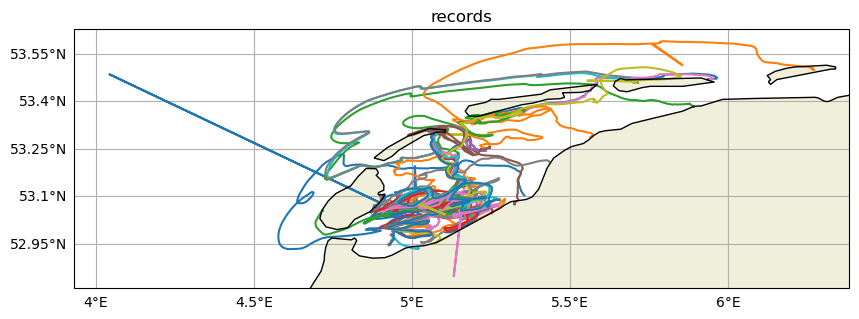

In [2]:
import xarray as xr
import pandas as pd
import numpy as np
from utils import *

observations = xr.open_dataset(input_netcdf_file, engine="netcdf4")
testing = False #TODO move to parameters section?
if testing:
  observations = observations.where((observations.trajectory=='Drifter10')|(observations.trajectory=='Drifter01'),drop=True)
  grounded_section = {"i_record":1,"t_start_isoformat":"2023-11-24 06:25:00.0+00:00","t_stop_isoformat":"2024-01-01 00:00:00.0+00:00"}
N_record = observations.dims["trajectory"]

if verbose:
  fig, ax = map_plot("records")
  for i in range(N_record):
    ax.plot(observations.lon.values[i], observations.lat.values[i])

observations if verbose else None

## 1 : Preprocessing

This section

* regulates outliers: entries with large displacements are removed, timesteps that lie too close together are combined

* defines timeseries according to minimum duration, minimum number of entries and maximum timedifference between successive timesteps

ts from record 0	n=2655
ts from record 1	n=1360
ts from record 2	n=2112
ts from record 3	n=433
ts from record 4	n=1361
ts from record 5	n=1034
ts from record 6	n=1399
ts from record 7	n=338
ts from record 8	n=251
ts from record 9	n=855
ts from record 10	n=1903
ts from record 11	n=9968
ts from record 12	n=823
ts from record 13	n=1321
ts from record 15	n=1328
ts from record 16	n=1869
ts from record 17	n=934
ts from record 17	n=1596
ts from record 18	n=1327
ts from record 19	n=1276
ts from record 20	n=1328
ts from record 21	n=1523
ts from record 22	n=2731
ts from record 23	n=1317
ts from record 24	n=404
ts from record 25	n=564
ts from record 26	n=1319
ts from record 27	n=1294
ts from record 28	n=2977
ts from record 29	n=1318
ts from record 30	n=1203


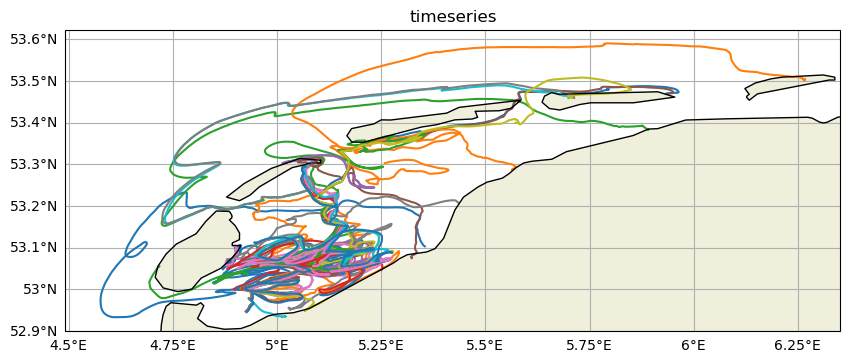

In [3]:
def convertTimeValues(dat_times, nan_value=0):
  times = np.array([[int(t)/1e9 if not(np.isnat(t)) else nan_value for t in ts]for ts in dat_times], dtype=np.int64)
  return times
dattimevalues = convertTimeValues(observations.time.values)

# cast data into records as as DataSets of variable lengths
record = []
for i in range(N_record):
  naninds = np.where(dattimevalues[i]==0)[0]
  n = np.min(naninds) if naninds.size else -1
  observation = {"time": dattimevalues[i,:n], "lon": observations.lon.values[i,:n], "lat": observations.lat.values[i,:n], "orientation": observations.orientation.values[i,:n], "sst": observations.SST.values[i,:n]}
  record += [pd.DataFrame(observation)] #.to_xarray()

# preprocessing
# extract time series from the records
timeseries = []
for i_record in range(N_record):
  n = record[i_record].shape[0]
  ts_list = []
  if n > 0:
    ts_list = [[[record[i_record]["time"][0], record[i_record]["lon"][0], record[i_record]["lat"][0], record[i_record]["orientation"][0], record[i_record]["sst"][0]]]]
    for i in range(1, n):
      # collect data at t0 and t1
      t0, lon0, lat0, orientation0, sst0 = ts_list[-1][-1]
      t1, lon1, lat1, orientation1, sst1 = [record[i_record]["time"][i], record[i_record]["lon"][i], record[i_record]["lat"][i], record[i_record]["orientation"][i], record[i_record]["sst"][i]]
      dt = t1 - t0

      # skip entries with large position differences
      if max_dpos_m < distance_coords_to_meters(lon0, lat0, lon1, lat1):
        continue

      # merge entries that are closer than min_dt_sec
      if dt < min_dt_sec:
        tm = (t0 + t1) / 2
        lonm = (lon0 + lon1) / 2
        latm = (lat0 + lat1) / 2
        sstm = (sst0 + sst1) / 2
        ts_list[-1][-1] = [tm, lonm, latm, orientation1, sstm]
        continue

      # split into two time series when entries are further apart than max_dt_sec
      if dt > max_dt_sec:
        ts_list += [[[t1, lon1, lat1, orientation1, sst1]]]
        continue

      # otherwise add entry to current time series
      ts_list[-1] += [[t1, lon1, lat1, orientation1, sst1]]

  # convert to np array and only keep ts that fulfill min_ts_duration_sec and min_ts_nsamp
  timeseries += [[]]
  for ts in ts_list:
    if min_ts_nsamp <= len(ts) and min_ts_duration_sec <= ts[-1][0] - ts[0][0]:
      ts = np.array(ts)
      timeseries[-1] += [pd.DataFrame({"time":ts[:,0], "lon":ts[:,1], "lat":ts[:,2], "orientation":ts[:,3], "sst":ts[:,4]}).to_xarray()]
      if verbose:
        print("ts from record %d\tn=%d" % (i_record, timeseries[-1][-1].index.values.shape[0]))

if verbose:
  fig, ax = map_plot("timeseries")
  for i_record in range(N_record):
    for ts in timeseries[i_record]:
      ax.plot(ts.lon, ts.lat)

## 2 : Downsampling

Reduces the timeseries according to the parameters 'downsample_execute', 'downsample_interval' and 'downsample_random_dropout_fraction' as defined above


Initial size > uniform intervals > randomized : 2655 > 2655 > 2655
Initial size > uniform intervals > randomized : 1360 > 1360 > 1360
Initial size > uniform intervals > randomized : 2112 > 2112 > 2112
Initial size > uniform intervals > randomized : 433 > 433 > 433
Initial size > uniform intervals > randomized : 1361 > 1361 > 1361
Initial size > uniform intervals > randomized : 1034 > 1034 > 1034
Initial size > uniform intervals > randomized : 1399 > 1399 > 1399
Initial size > uniform intervals > randomized : 338 > 338 > 338
Initial size > uniform intervals > randomized : 251 > 251 > 251
Initial size > uniform intervals > randomized : 855 > 855 > 855
Initial size > uniform intervals > randomized : 1903 > 1903 > 1903
Initial size > uniform intervals > randomized : 9968 > 9968 > 9968
Initial size > uniform intervals > randomized : 823 > 823 > 823
Initial size > uniform intervals > randomized : 1321 > 1321 > 1321
Initial size > uniform intervals > randomized : 1328 > 1328 > 1328
Initial si

<xarray.Dataset> Size: 149kB
Dimensions:         (index: 2655, index_original: 2655)
Coordinates:
  * index           (index) int64 21kB 0 1 2 3 4 5 ... 2650 2651 2652 2653 2654
  * index_original  (index_original) int64 21kB 0 1 2 3 ... 2651 2652 2653 2654
Data variables:
    time            (index) float64 21kB 1.7e+09 1.7e+09 ... 1.701e+09 1.701e+09
    lon             (index) float64 21kB 4.925 4.926 4.927 ... 5.352 5.354 5.355
    lat             (index) float64 21kB 52.95 52.95 52.95 ... 53.1 53.1 53.1
    orientation     (index) float64 21kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 1.0 1.0
    sst             (index) float64 21kB 11.1 11.1 11.1 ... 9.094 9.07 9.047

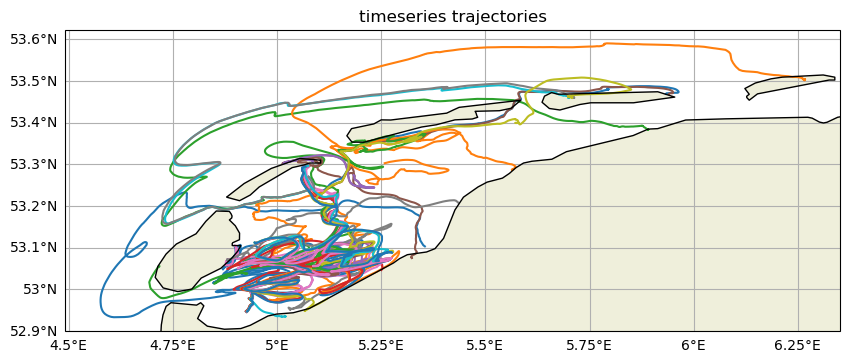

In [4]:
np.random.seed(0)
for i_record in range(N_record):
  for i_ts in range(len(timeseries[i_record])):
    ts = timeseries[i_record][i_ts]
    N = ts.index.values.shape[0]
    inds_downsampled = np.array(range(0,N,downsample_interval))
    N_ds = inds_downsampled.shape[0]
    N_ds_drop = int(N_ds*(1.-downsample_random_dropout_fraction))
    np.random.shuffle(inds_downsampled)
    inds_rnd_dropped = inds_downsampled[:N_ds_drop]
    inds_rnd_dropped = np.sort(inds_rnd_dropped)
    ts = ts.isel(index=inds_rnd_dropped)
    ts['index'] = np.array(range(N_ds_drop))
    ts['index_original'] = inds_rnd_dropped
    timeseries[i_record][i_ts] = ts
    if verbose:
      print("Initial size > uniform intervals > randomized : %d > %d > %d" % (N, N_ds, N_ds_drop))

if verbose:
  fig, ax = map_plot("timeseries trajectories")
  for i_record in range(N_record):
    for i_ts in range(len(timeseries[i_record])):
      ts = timeseries[i_record][i_ts]
      ax.plot(ts.lon.values, ts.lat.values)

timeseries[0][0] if verbose else None

## 3 : Derived Quantities

This section

* derives quantities for each timeseries, such as position accuracy, geodesic distances, velocities, directions of displacements

* integrates the table of manually labelled events

* adds metadata for the datasets

### 3.1 : Compute stdev of the positioning system

no_samples=7272 stdev_x=4.722976 stdev_y=6.405357


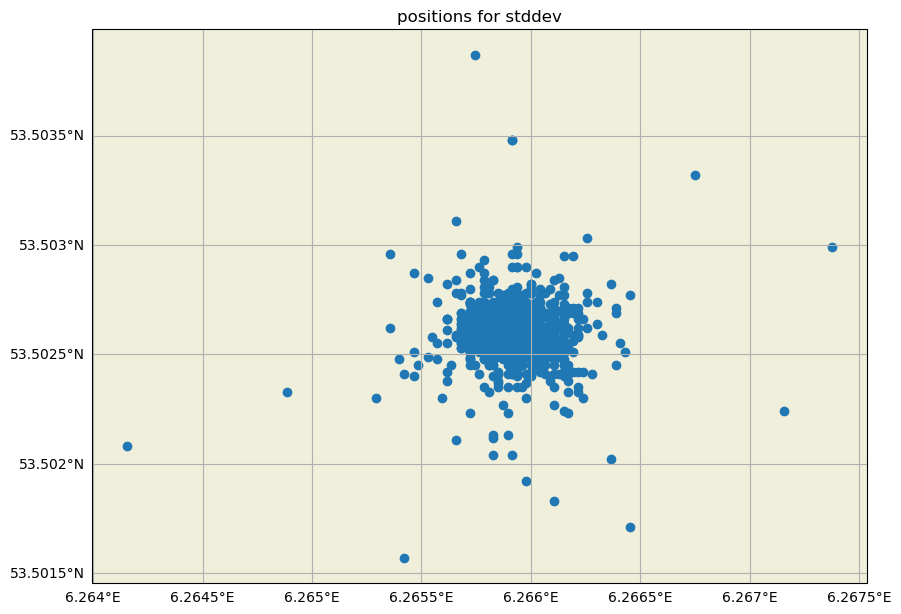

stdev_position_meters=6.405357


In [5]:
from datetime import datetime
from utils import *

if grounded_section:
  # get positions of the grounded section
  t_start = datetime.fromisoformat(grounded_section["t_start_isoformat"]).timestamp()
  t_stop = datetime.fromisoformat(grounded_section["t_stop_isoformat"]).timestamp()
  lons = np.array([])
  lats = np.array([])
  for ts in timeseries[grounded_section["i_record"]]:
    ts_slice = ts.where((ts.time>=t_start)&(ts.time<=t_stop),drop=True)
    lons = np.concatenate([lons,np.array(ts_slice.lon.values)])
    lats = np.concatenate([lats,np.array(ts_slice.lat.values)])
  # derive accuracy of positions
  N = lons.shape[0]
  mlons = np.mean(lons)
  mlats = np.mean(lats)
  slons = np.std(mlons-lons)
  slats = np.std(mlats-lats)
  sx = distance_coords_to_meters(mlons, mlats, mlons+slons, mlats)
  sy = distance_coords_to_meters(mlons, mlats, mlons, mlats+slats)

  stdev_position_meters = max(sx, sy)
  if verbose:
    print("no_samples=%d stdev_x=%f stdev_y=%f" % (N, sx, sy))
    fig, ax = map_plot("positions for stddev")
    ax.scatter(lons,lats)
    plt.show()

if verbose:
  print("stdev_position_meters=%f" % stdev_position_meters)

### 3.2 : Additional timeseries quantities

In [6]:
tracks = []
for i_record in range(N_record):
  for i_ts, ts in enumerate(timeseries[i_record]):
    n = ts.index.values.shape[0]
    position_gaussian_noise = np.random.normal(0, stdev_position_meters, size=(n,2))
    ts["t"] = ts.time - ts.time.values[0]
    for label in ["s", "v", "alp", "alp_noise_augmented", "dt", "ds", "dx", "dy"]:
      ts[label]=ts["t"]*np.nan
    ts.s[0] = 0
    for i in range(n-1):
      ts.dt[i] = ts.time[i+1] - ts.time[i]
      ts.ds[i] = distance_coords_to_meters(ts.lon[i], ts.lat[i], ts.lon[i+1], ts.lat[i+1])
      ts.dx[i] = np.sign(ts.lon[i+1] - ts.lon[i]) * distance_coords_to_meters(ts.lon[i], ts.lat[i], ts.lon[i+1], ts.lat[i])
      ts.dy[i] = np.sign(ts.lat[i+1] - ts.lat[i]) * distance_coords_to_meters(ts.lon[i], ts.lat[i], ts.lon[i], ts.lat[i+1])
      ts.s[i+1] = ts.s[i] + ts.ds[i]
      ts.alp[i] = directionNE(ts.dx[i],ts.dy[i])
      ndx, ndy = position_gaussian_noise[i]
      ts.alp_noise_augmented[i] = directionNE(ts.dx[i]+ndx,ts.dy[i]+ndy)
      ts.v[i] = ts.ds[i] / ts.dt[i]
    ts.attrs = {"i_record" : i_record, "i_ts" : i_ts}
    tracks += [ts]

tracks[0] if verbose else None

<xarray.Dataset> Size: 340kB
Dimensions:              (index: 2655, index_original: 2655)
Coordinates:
  * index                (index) int64 21kB 0 1 2 3 4 ... 2651 2652 2653 2654
  * index_original       (index_original) int64 21kB 0 1 2 3 ... 2652 2653 2654
Data variables: (12/14)
    time                 (index) float64 21kB 1.7e+09 1.7e+09 ... 1.701e+09
    lon                  (index) float64 21kB 4.925 4.926 4.927 ... 5.354 5.355
    lat                  (index) float64 21kB 52.95 52.95 52.95 ... 53.1 53.1
    orientation          (index) float64 21kB 0.0 0.0 0.0 0.0 ... 0.0 1.0 1.0
    sst                  (index) float64 21kB 11.1 11.1 11.1 ... 9.07 9.047
    t                    (index) float64 21kB 0.0 246.0 ... 8.267e+05 8.27e+05
    ...                   ...
    alp                  (index) float64 21kB 0.5708 0.574 0.6191 ... 2.443 nan
    alp_noise_augmented  (index) float64 21kB 0.5858 0.599 0.6492 ... 2.466 nan
    dt                   (index) float64 21kB 246.0 308.0 366.0 ... 325.0 nan
    ds                   (index) float64 21kB 84.57 113.9 173.4 ... 138.0 nan
    dx                   (index) float64 21kB 45.69 61.84 100.6 ... 88.79 nan
    dy                   (index) float64 21kB 71.16 95.63 141.2 ... -105.6 nan
Attributes:
    i_record:  0
    i_ts:      0

## 4 : Adding annotations and metadata

In [7]:
# processing of timeseries
ts_creation_parameters = {'preprocessing_min_dt' : min_dt_sec, 'preprocessing_max_dt' : max_dt_sec, 'preprocessing_min_ts_duration' : min_ts_duration_sec, 'preprocessing_min_ts_nsamp' : min_ts_nsamp}
info = {'units' : "meters for distances, seconds for times, celsius for temperatures, degrees for coordinates, radians for directions. Timestamps are Unix epochs in seconds. Directions range from 0 to 2pi with north at 0 and east at pi/2. Orientations are given as booleans for up and down"} | ts_creation_parameters
for i in range(len(tracks)):
  #ts = ts.to_xarray()
  tracks[i].attrs |= {"drifter_name" : str(observations.trajectory[i_record]), "stdev_position_meters" : stdev_position_meters} | info

tracks[0] if verbose else None

<xarray.Dataset> Size: 340kB
Dimensions:              (index: 2655, index_original: 2655)
Coordinates:
  * index                (index) int64 21kB 0 1 2 3 4 ... 2651 2652 2653 2654
  * index_original       (index_original) int64 21kB 0 1 2 3 ... 2652 2653 2654
Data variables: (12/14)
    time                 (index) float64 21kB 1.7e+09 1.7e+09 ... 1.701e+09
    lon                  (index) float64 21kB 4.925 4.926 4.927 ... 5.354 5.355
    lat                  (index) float64 21kB 52.95 52.95 52.95 ... 53.1 53.1
    orientation          (index) float64 21kB 0.0 0.0 0.0 0.0 ... 0.0 1.0 1.0
    sst                  (index) float64 21kB 11.1 11.1 11.1 ... 9.07 9.047
    t                    (index) float64 21kB 0.0 246.0 ... 8.267e+05 8.27e+05
    ...                   ...
    alp                  (index) float64 21kB 0.5708 0.574 0.6191 ... 2.443 nan
    alp_noise_augmented  (index) float64 21kB 0.5858 0.599 0.6492 ... 2.466 nan
    dt                   (index) float64 21kB 246.0 308.0 366.0 ... 325.0 nan
    ds                   (index) float64 21kB 84.57 113.9 173.4 ... 138.0 nan
    dx                   (index) float64 21kB 45.69 61.84 100.6 ... 88.79 nan
    dy                   (index) float64 21kB 71.16 95.63 141.2 ... -105.6 nan
Attributes:
    i_record:                       0
    i_ts:                           0
    drifter_name:                   <xarray.DataArray 'trajectory' ()> Size: ...
    stdev_position_meters:          6.405357115545444
    units:                          meters for distances, seconds for times, ...
    preprocessing_min_dt:           200
    preprocessing_max_dt:           1700
    preprocessing_min_ts_duration:  5400
    preprocessing_min_ts_nsamp:     36

### 4.1 : Manual labels events

In [8]:
def get_manual_labels_and_indices_where(tr, eventtype=None):
  irecord, its = tr.attrs['i_record'], tr.attrs['i_ts']
  ds = xr.open_dataset("data/out/waddendrifters2023_grounding_events_manual_coding.nc", engine="netcdf4").load()
  inds = (ds.irecord==irecord)&(ds.its==its)&((ds.tag==eventtype) if eventtype else True)
  entries = ds.where(inds,drop=True)
  entries['ind_start'].values = map_to_next_available_index(entries.ind_start.values, tr.index_original.values)[:,1]
  n = int(entries.count(dim='index').tag)
  return entries, n

def load_grounding_labels_and_attach_to_tracks(tracks):
  for tr in tracks:
    N = tr.lon.values.shape[0]
    inds = tr.index.values
    grounded_transitions = np.zeros(N)
    beached_transitions = np.zeros(N)
    tr['label']=tr["time"]*np.zeros(N) # hacky way to add data variable
    entries, ne = get_manual_labels_and_indices_where(tr)
    for ie in range(ne):
      label, ind = entries.tag.values[ie], entries.ind_start.values[ie]
      tr['label'].values[ind] = -1 if label in ['W'] else (1 if label in ['D'] else (2 if label in ['B'] else 0))
    for ie in range(ne):
      label, ind = entries.tag.values[ie], entries.ind_start.values[ie]
      if label in ['W']:
        grounded_transitions[ind] = -1
      if label in ['D', 'B']:
        grounded_transitions[ind] = +1
      if label in ['B']:
        beached_transitions[ind] = +1
      if label in ['W']:
        beached_transitions[ind] = -1
    grounded_initial_state = grounded_transitions[np.argwhere(grounded_transitions!=0)[0] if np.sum(grounded_transitions!=0) else 0] == -1
    grounded = np.full(N, grounded_initial_state)
    beached_initial_state = True if beached_transitions[0]==+1 else False
    beached = np.full(N, beached_initial_state)
    for i in range(1,N):
      if grounded_transitions[i] != 0:
        grounded[i] = (grounded_transitions[i] == +1)
      else:
        grounded[i] = grounded[i-1]
      if beached_transitions[i] != 0:
        beached[i] = (beached_transitions[i] == +1)
      else:
        beached[i] = beached[i-1]
    tr['grounded']=tr["time"]*np.nan # hacky way to add data variable
    tr['grounded'].values=grounded
    tr['beached']=tr["time"]*np.nan # hacky way to add data variable
    tr['beached'].values=beached
    dt_section = np.zeros(N)
    i_toggle = 0
    for i in range(1,N):
      if tr["grounded"][i-1] != tr["grounded"][i]:
        dt_section[i_toggle:i] = tr.t[inds[i]]-tr.t[i_toggle]
        i_toggle = i
    dt_section[i_toggle:] = tr.t[-1]-tr.t[i_toggle]
    tr["dt_section"]=tr["time"]*np.nan # hacky way to add data variable
    tr["dt_section"].values=dt_section

  if verbose:
    print(get_manual_labels_and_indices_where(tracks[0], 'D'))
  return tracks

tracks = load_grounding_labels_and_attach_to_tracks(tracks)

tracks[0] if verbose else None

(<xarray.Dataset> Size: 72B
Dimensions:    (index: 2)
Coordinates:
  * index      (index) int64 16B 0 2
Data variables:
    ind_start  (index) int32 8B 668 933
    tag        (index) object 16B 'D' 'D'
    irecord    (index) float64 16B 0.0 0.0
    its        (index) float64 16B 0.0 0.0
Attributes:
    occurring_irecord:  [ 0  0  1  1  2  2  3  3  4  4  5  5  6  6  7  7  8  ...
    occurring_its:      [0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 ..., 2)


<xarray.Dataset> Size: 388kB
Dimensions:              (index: 2655, index_original: 2655)
Coordinates:
  * index                (index) int64 21kB 0 1 2 3 4 ... 2651 2652 2653 2654
  * index_original       (index_original) int64 21kB 0 1 2 3 ... 2652 2653 2654
Data variables: (12/18)
    time                 (index) float64 21kB 1.7e+09 1.7e+09 ... 1.701e+09
    lon                  (index) float64 21kB 4.925 4.926 4.927 ... 5.354 5.355
    lat                  (index) float64 21kB 52.95 52.95 52.95 ... 53.1 53.1
    orientation          (index) float64 21kB 0.0 0.0 0.0 0.0 ... 0.0 1.0 1.0
    sst                  (index) float64 21kB 11.1 11.1 11.1 ... 9.07 9.047
    t                    (index) float64 21kB 0.0 246.0 ... 8.267e+05 8.27e+05
    ...                   ...
    dx                   (index) float64 21kB 45.69 61.84 100.6 ... 88.79 nan
    dy                   (index) float64 21kB 71.16 95.63 141.2 ... -105.6 nan
    label                (index) float64 21kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    grounded             (index) bool 3kB False False False ... False False
    beached              (index) bool 3kB False False False ... False False
    dt_section           (index) float64 21kB 2.078e+05 2.078e+05 ... 3.585e+05
Attributes:
    i_record:                       0
    i_ts:                           0
    drifter_name:                   <xarray.DataArray 'trajectory' ()> Size: ...
    stdev_position_meters:          6.405357115545444
    units:                          meters for distances, seconds for times, ...
    preprocessing_min_dt:           200
    preprocessing_max_dt:           1700
    preprocessing_min_ts_duration:  5400
    preprocessing_min_ts_nsamp:     36

## 5 : Data output

In [9]:
import os
import shutil

output_dir = "data/out/sample_interval_%d_rnd_drop_fraction_%.2f"%(downsample_interval,downsample_random_dropout_fraction)
if os.path.exists(output_dir):
  shutil.rmtree(output_dir)
os.makedirs(output_dir)

for i in range(len(tracks)):
  out_file = "%s/trajectory_%d.nc" % (output_dir, i)
  tracks[i].to_netcdf(out_file)
  if verbose:
    print("written %s" % out_file)

written data/out/sample_interval_1_rnd_drop_fraction_0.00/trajectory_0.nc
written data/out/sample_interval_1_rnd_drop_fraction_0.00/trajectory_1.nc
written data/out/sample_interval_1_rnd_drop_fraction_0.00/trajectory_2.nc
written data/out/sample_interval_1_rnd_drop_fraction_0.00/trajectory_3.nc
written data/out/sample_interval_1_rnd_drop_fraction_0.00/trajectory_4.nc
written data/out/sample_interval_1_rnd_drop_fraction_0.00/trajectory_5.nc
written data/out/sample_interval_1_rnd_drop_fraction_0.00/trajectory_6.nc
written data/out/sample_interval_1_rnd_drop_fraction_0.00/trajectory_7.nc
written data/out/sample_interval_1_rnd_drop_fraction_0.00/trajectory_8.nc
written data/out/sample_interval_1_rnd_drop_fraction_0.00/trajectory_9.nc
written data/out/sample_interval_1_rnd_drop_fraction_0.00/trajectory_10.nc
written data/out/sample_interval_1_rnd_drop_fraction_0.00/trajectory_11.nc
written data/out/sample_interval_1_rnd_drop_fraction_0.00/trajectory_12.nc
written data/out/sample_interval_1_